# 06 · Los frenos de seguridad del agente

**Qué pregunta responde este cuaderno.** ¿Qué impide que el agente entre en un bucle, copie una cifra mal,
introduzca un importe falso en la explicación o estime un dato ausente del corpus?

Los *guardrails* son código Python entre el modelo, sus herramientas y la respuesta final. Contrastan la
salida con lo que devolvieron las herramientas; no dependen de que el modelo descubra su propio error.

**Cómo se comprueba.** Los apartados 1–3 usan un modelo de guion y datos reales del corpus. Provocamos los
fallos deliberadamente y comprobamos la salida con `assert`. No llaman a ninguna API. La búsqueda de las
demos es un doble que devuelve una frase real del corpus: aquí se prueba el control, no la calidad del retrieval.
El apartado 4 permite tres preguntas con el modelo real, desactivadas por defecto.

| Protección | Qué comprueba | Si falla |
| --- | --- | --- |
| Máximo 8 llamadas a herramientas | Presupuesto por pregunta | Bloquea la novena |
| Máximo 1 llamada a `read_section` | Presupuesto de lectura | Bloquea la segunda |
| Máximo 10 llamadas al modelo | Bucle que no concluye | Termina y rescata una salida estructurada |
| Cifras XBRL | Valores, escalas, unidades, ejercicios y concepto | Repara si es inequívoco; si no, pide una corrección y retira cifras persistentes |
| Importes de la explicación | Respaldo numérico en XBRL o texto consultado | Pide corrección; si persiste, retira la explicación y conserva los campos verificados |
| Citas | Literalidad y procedencia en texto visto | Pide una cita válida; si persiste, retira la cita y la explicación sin verificar |
| Honestidad ante huecos | No estimar un dato que falta en el corpus | Abstención sin cifras ni estimaciones |

**Límites.** Una cifra presente en la evidencia puede estar mal atribuida en una frase; una cita literal
puede no respaldar la explicación. Estos controles deterministas no son un juez semántico general.
Los porcentajes no se contrastan como importes USD; en las abstenciones sí se eliminan las estimaciones,
incluidos porcentajes. «No está en el corpus» no significa «la empresa nunca lo publica».

1. Tope de llamadas y rescate del ejercicio solicitado.
2. Reparaciones, reintento, retirada, importes en prosa y citas.
3. Honestidad ante huecos y estimaciones ocultas en el texto.
4. Diagnóstico opcional con modelo real y trazas guardadas.
5. Cierre y relación con la evaluación del notebook 7.

Requisitos R04, R05 y R14 ([enunciado](../docs/00_enunciado.md)) · Código:
[guardrails.py](../src/agente10k/guardrails.py).

In [1]:
# Arranque (igual en todos los notebooks): localiza la raíz del repo y hace importable src/
import sys, pathlib
RAIZ = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(RAIZ / "src"))
from agente10k import config

In [2]:
# Solo activa las tres preguntas reales del apartado 4; los apartados 1–3 siempre son locales.
EJECUTAR = True
MODELO_REAL = config.MODELO_ID

In [3]:
# Piezas comunes a las demos de §1 y §3: un modelo FALSO (GenericFakeChatModel, sin red) que
# ejecuta un guion de mensajes fijado de antemano, y una herramienta search_filings de juguete
# (mismo patrón que tests/test_guardrails_middleware.py). get_xbrl_fact, read_section y
# list_available SÍ son las reales: leen data/corpus/, no llaman a ningún modelo.
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display
from langchain.agents import create_agent
from langchain.agents.structured_output import ToolStrategy
from langchain.messages import AIMessage, HumanMessage, ToolMessage
from langchain.tools import tool
from langchain_core.language_models.fake_chat_models import GenericFakeChatModel
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.errors import GraphRecursionError

from agente10k import datos, guardrails as g
from agente10k.agente import RespuestaFinanciera
from agente10k.herramientas import get_xbrl_fact, list_available, read_section

COLOR_SIN = "#c0392b"   # sin guardrail: rojo
COLOR_CON = "#1f8a4c"   # con guardrail: verde
COLOR_NEUTRO = "#4472c4"


# Frase auténtica, elegida sin llamar al buscador: el doble no evalúa BM25.
filas_cita = datos.cargar_chunks()
filas_cita = filas_cita[(filas_cita.ticker == "MSFT") & (filas_cita.fiscal_year == 2025)
                        & (filas_cita.item == "1A")]
CHUNK_DEMO, CITA_DEMO = next(
    (r["chunk_id"], frase)
    for r in filas_cita.to_dict("records") for frase in g.trocear(r["texto"])
    if 8 <= len(frase.split()) <= 100 and not g.importes_prosa(frase)
)
BUSQUEDAS_DEMO = []


@tool("search_filings")
def search_filings_doble(query: str, ticker: str | None = None, fiscal_year: int | None = None,
                         item: str | None = None, k: int = 5) -> str:
    """Doble controlado: devuelve una frase real, sin buscar en un índice ni llamar a un modelo."""
    BUSQUEDAS_DEMO.append(query)
    return f"[{CHUNK_DEMO}] MSFT FY2025 Item 1A · BM25 1.0\n{CITA_DEMO}"


class ModeloDeGuion(GenericFakeChatModel):
    """GenericFakeChatModel que cuenta sus llamadas; acepta bind_tools() como create_agent lo exige."""

    n: int = 0

    def bind_tools(self, tools, **kw):
        return self

    def _generate(self, messages, *a, **k):
        object.__setattr__(self, "n", self.n + 1)
        return super()._generate(messages, *a, **k)


def tc(nombre: str, args: dict, i: int) -> AIMessage:
    """Un AIMessage con una única tool_call, como en tests/test_guardrails_middleware.py."""
    return AIMessage(content="", tool_calls=[{"name": nombre, "args": args, "id": f"c{i}"}])


def respuesta_final(i: int, **kw) -> AIMessage:
    """El AIMessage con el que el modelo de guion 'llama' a la tool sintética RespuestaFinanciera."""
    return tc("RespuestaFinanciera", {"respuesta": "x", "fuente": "xbrl", **kw}, i)


def correr_agente(mensajes, *, middleware, recursion_limit: int = 100, pregunta: str = "pregunta de demo"):
    """Agente real (create_agent) con el modelo de guion y las herramientas reales/dobles.

    Devuelve (resultado_o_None, modelo). Si el grafo se queda sin pasos (GraphRecursionError),
    se captura para poder mostrar cuántas llamadas hizo el modelo antes del corte.
    """
    modelo = ModeloDeGuion(messages=iter(mensajes))
    agente_demo = create_agent(
        model=modelo, tools=[get_xbrl_fact, search_filings_doble, read_section, list_available],
        response_format=ToolStrategy(schema=RespuestaFinanciera), middleware=middleware,
        checkpointer=InMemorySaver())
    cfg = {"configurable": {"thread_id": f"demo-{id(modelo)}"}, "recursion_limit": recursion_limit}
    try:
        resultado = agente_demo.invoke({"messages": [{"role": "user", "content": pregunta}]}, config=cfg)
    except GraphRecursionError:
        resultado = None
    return resultado, modelo

## 1. El tope de llamadas: cuándo hay que rendirse

**La situación.** El corpus no contiene `GrossProfit` de Amazon para esos ejercicios: es uno de los huecos
reales del corpus. Un agente que no sabe rendirse puede preguntar por él una y otra vez, cambiando el ejercicio
en cada intento, sin llegar nunca a ninguna parte. Cada vuelta cuesta tiempo y dinero.

**El experimento.** Usamos un modelo de mentira programado para pedir siempre la misma herramienta, y lo
lanzamos dos veces con la misma pregunta: una sin frenos y otra con los frenos del sistema final.

Guía: [09 §2](../docs/09_skill_guardrails_middleware_xbrl.md)

In [4]:
AMZN_GROSS = {"ticker": "AMZN", "fiscal_year": 2025, "concept": "GrossProfit"}
PREGUNTA_BUCLE = "¿Cuál fue el margen bruto de AMZN en el ejercicio fiscal 2025?"


def bucle_infinito():
    """El modelo pide SIEMPRE get_xbrl_fact, alternando el ejercicio: nunca produce RespuestaFinanciera."""
    i = 0
    while True:
        i += 1
        yield tc("get_xbrl_fact", {**AMZN_GROSS, "fiscal_year": 2024 if i % 2 else 2025}, i)


# SIN guardrails: solo el arnés (recursion_limit=100, igual que el baseline). El modelo nunca se
# rinde, así que el grafo corta por recursion_limit con GraphRecursionError (sin middleware, cada
# vuelta cuesta ~2 pasos: se agotan en torno a 50 tool calls, docs/09 §2).
res_sin, modelo_sin = correr_agente(bucle_infinito(), middleware=[], recursion_limit=100,
                                    pregunta=PREGUNTA_BUCLE)

# CON guardrails: la pila real del sistema final. ModelCallLimit(10, "end") corta a las 10
# llamadas al modelo y GuardrailsFinal.after_agent rescata una respuesta honesta del ledger.
res_con, modelo_con = correr_agente(bucle_infinito(), middleware=g.middleware_final(),
                                    pregunta=PREGUNTA_BUCLE)

resp_con = res_con["structured_response"]
guard_con = res_con.get("guard") or {}
print(f"SIN guardrails: {modelo_sin.n} llamadas al modelo, "
      f"{'cortado por recursion_limit (GraphRecursionError)' if res_sin is None else 'terminó solo'}, "
      "sin structured_response garantizada.")
print(f"CON guardrails: {modelo_con.n} llamadas al modelo (tope = {g.RUN_LIMIT_MODELO}).")
print(f"  causa: {guard_con.get('causa')} · degradada: {guard_con.get('degradada')}")
print(f"  fuente: {resp_con.fuente!r} · cifra: {resp_con.cifra!r}")
print(f"  respuesta: {resp_con.respuesta!r}")
assert modelo_con.n <= g.RUN_LIMIT_MODELO
assert resp_con.fuente == "ninguna" and resp_con.cifra is None      # nunca inventa el margen bruto
assert resp_con.ejercicio == 2025 and "FY2025" in resp_con.respuesta

SIN guardrails: 50 llamadas al modelo, cortado por recursion_limit (GraphRecursionError), sin structured_response garantizada.
CON guardrails: 10 llamadas al modelo (tope = 10).
  causa: grafo_terminado_sin_respuesta · degradada: True
  fuente: 'ninguna' · cifra: None
  respuesta: 'No reportado en XBRL para AMZN FY2025: el dato no está en el corpus.'


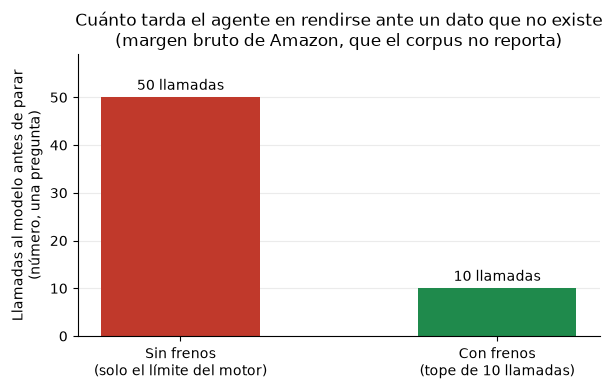

In [5]:
fig, ax = plt.subplots(figsize=(6.2, 4))
etiquetas_barras = ["Sin frenos\n(solo el límite del motor)", f"Con frenos\n(tope de {g.RUN_LIMIT_MODELO} llamadas)"]
valores_barras = [modelo_sin.n, modelo_con.n]
barras = ax.bar(etiquetas_barras, valores_barras, color=[COLOR_SIN, COLOR_CON], width=0.5)
ax.bar_label(barras, labels=[f"{v} llamadas" for v in valores_barras], padding=3)
ax.set_ylabel("Llamadas al modelo antes de parar\n(número, una pregunta)")
ax.set_ylim(0, max(valores_barras) * 1.18)
ax.set_title("Cuánto tarda el agente en rendirse ante un dato que no existe\n"
             "(margen bruto de Amazon, que el corpus no reporta)")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


**Qué demuestra:** el bucle controlado pasa de 50 a 10 llamadas al modelo y devuelve una abstención sobre
**FY2025**, el ejercicio solicitado, aunque también se consultó FY2024. Son cinco veces menos llamadas en
este guion; no se han medido tokens ni coste monetario. El rescate solo atribuye un hueco a un ejercicio cuya
consulta confirmó la ausencia; si solo se consultó otro, indica que no ha podido verificar el dato pedido.

### 1.1. Los otros dos límites, por separado

Se envían nueve búsquedas **distintas**, para que no sea el detector de duplicados el que las bloquee.
Después se piden dos secciones diferentes: solo la primera debe llegar a `read_section`.

In [6]:
BUSQUEDAS_DEMO.clear()
res_tools, _ = correr_agente(
    [tc("search_filings", {"query": f"risk case {i}", "ticker": "MSFT"}, i) for i in range(1, 10)]
    + [respuesta_final(10, fuente="ninguna", respuesta="No he obtenido una respuesta verificable.")],
    middleware=g.middleware_final(camino_rapido=False),
)
novena = next(m for m in res_tools["messages"] if isinstance(m, ToolMessage) and m.tool_call_id == "c9")
assert len(BUSQUEDAS_DEMO) == 8 and "limit exceeded" in str(novena.content).lower()

res_lectura, _ = correr_agente([
    tc("read_section", {"ticker": "NVDA", "fiscal_year": 2025, "item": "7A"}, 1),
    tc("read_section", {"ticker": "NVDA", "fiscal_year": 2025, "item": "7"}, 2),
    respuesta_final(3, fuente="ninguna", respuesta="No he obtenido una respuesta verificable."),
], middleware=g.middleware_final(camino_rapido=False))
lecturas = [m for m in res_lectura["messages"] if isinstance(m, ToolMessage) and m.name == "read_section"]
assert len(lecturas) == 2
assert "limit exceeded" not in str(lecturas[0].content).lower()
assert "limit exceeded" in str(lecturas[1].content).lower()
assert res_tools["structured_response"] is not None and res_lectura["structured_response"] is not None

display(pd.DataFrame([
    {"límite": "Herramientas", "solicitadas": 9, "ejecutadas": len(BUSQUEDAS_DEMO), "bloqueada": "9.ª"},
    {"límite": "read_section", "solicitadas": 2, "ejecutadas": 1, "bloqueada": "2.ª"},
]))
print("Aviso de la novena búsqueda:", novena.content)
print("Aviso de la segunda lectura:", lecturas[1].content)

,límite,solicitadas,ejecutadas,bloqueada
0,Herramientas,9,8,9.ª
1,read_section,2,1,2.ª


Aviso de la novena búsqueda: Tool call limit exceeded. Do not make additional tool calls.
Aviso de la segunda lectura: Tool call limit exceeded. Do not call 'read_section' again.


## 2. Verificación de cifras: dato, texto y pregunta

El registro XBRL conserva los hechos consultados. Se comparan `cifra` y `cifra_base` con ese registro usando
la tolerancia compartida con el evaluador: **USD, 0,5 % relativo; BPA, 0,005 absoluto**. Algunos errores de
escala u orientación se reparan sin pedir otra vuelta. Un valor distinto requiere corrección del modelo.

Además se extraen importes del texto `respuesta`: un campo `cifra` correcto no permite afirmar otra cantidad
sin respaldo en la explicación. La evidencia textual procede de las observaciones, nunca de una cita que el
modelo acaba de inventar. Se admiten diferencias entre ejercicios del mismo concepto, empresa y unidad.
Esto comprueba apoyo numérico, no que todos los números están atribuidos semánticamente al concepto correcto.

El extractor reconoce formatos españoles e ingleses. Los porcentajes no se verifican como importes XBRL;
por eso la abstención ante datos ausentes tiene su propio control en el apartado 3.

In [7]:
ejemplos_prosa = [
    "391 billones de dólares",
    "El BPA fue de 2,97 USD por acción, tras el split 10:1 (FY2025, Item 7)",
    "Ingresos de $60,922 millones y 44.301 millones de USD",
    "creció un 14,9 %",  # los porcentajes no cuentan como cifra XBRL
]
for texto in ejemplos_prosa:
    print(f"{texto!r:65s} -> {g.extraer_cifras(texto)}")

'391 billones de dólares'                                         -> [391000000000000.0]
'El BPA fue de 2,97 USD por acción, tras el split 10:1 (FY2025, Item 7)' -> [2.97]
'Ingresos de $60,922 millones y 44.301 millones de USD'           -> [60922000000.0, 44301000000.0]
'creció un 14,9 %'                                                -> []


### 2.1. Tres desajustes con datos reales y respuestas simuladas

1. **Escala:** ingresos de NVIDIA FY2024, valor expresado sin sus millones.
2. **BPA básico/diluido:** la pregunta pide explícitamente el básico. Aunque 6,08 sea un valor real del
   diluido, cambiar la etiqueta no responde a la pregunta: debe pedir una corrección.
3. **Comparación invertida:** se intercambian cifras y ejercicios de NVIDIA.

Solo los casos 1 y 3 son reparaciones automáticas completas. El caso 2 necesita un reintento, mostrado debajo.
El reconocimiento de la magnitud pedida es léxico y conservador; no comprende cualquier pregunta financiera.

In [8]:
def ledger_real(*consultas):
    """Ledger construido con llamadas REALES a get_xbrl_fact sobre el parquet del corpus (sin red, sin LLM)."""
    msgs = []
    for i, (ticker, fy, concept) in enumerate(consultas):
        args = {"ticker": ticker, "fiscal_year": fy, "concept": concept}
        msgs.append(AIMessage(content="", tool_calls=[{"name": "get_xbrl_fact", "id": f"v{i}", "args": args}]))
        msgs.append(ToolMessage(content=str(get_xbrl_fact.invoke(args)), tool_call_id=f"v{i}", name="get_xbrl_fact"))
    return g.libro_hechos(msgs)


casos = []

# 1. Escala mal: NVDA Revenues FY2024 — el modelo copia el valor "sin escalar" (60.922 en vez de 60.922.000.000)
decl1 = {"respuesta": "x", "fuente": "xbrl", "cifra": 60_922, "unidad": "USD", "ticker": "NVDA", "ejercicio": 2024}
inf1 = g.verificar_xbrl(decl1, ledger_real(("NVDA", 2024, "Revenues")), [])
casos.append({"caso": "1. Escala mal (NVDA Revenues FY2024)",
             "declarado": f"{decl1['cifra']:,} {decl1['unidad']}",
             "verificado": f"{inf1.resp['cifra']:,.0f} {inf1.resp['unidad']}",
             "reparaciones": ", ".join(c for c, _ in inf1.reparaciones), "problemas_sin_resolver": len(inf1.problemas)})

# 2. BPA básico confundido con diluido: AAPL FY2024 (declara "básico" pero el valor es el diluido)
decl2 = {"respuesta": "x", "fuente": "xbrl", "cifra": 6.08, "unidad": "USD/shares", "ticker": "AAPL",
         "ejercicio": 2024, "concept_xbrl": "EarningsPerShareBasic"}
inf2 = g.verificar_xbrl(decl2, ledger_real(("AAPL", 2024, "EarningsPerShareBasic"),
                                           ("AAPL", 2024, "EarningsPerShareDiluted")), [],
                        pregunta="¿Cuál fue el BPA básico de AAPL en FY2024?")
casos.append({"caso": "2. BPA básico↔diluido (AAPL FY2024)",
             "declarado": f"{decl2['cifra']} USD/shares · concept={decl2['concept_xbrl']}",
             "verificado": f"{inf2.resp['cifra']} USD/shares · concept={inf2.resp['concept_xbrl']}",
             "reparaciones": ", ".join(c for c, _ in inf2.reparaciones), "problemas_sin_resolver": len(inf2.problemas)})

# 3. Comparativa con orientación invertida: NVDA EPS FY2025 vs FY2024 (cifra/cifra_base cambiadas de sitio)
decl3 = {"respuesta": "x", "fuente": "xbrl", "cifra": 12.05, "cifra_base": 2.97, "unidad": "USD/shares",
         "ticker": "nvidia", "ejercicio": 2024, "ejercicio_base": 2025, "concept_xbrl": "EarningsPerShareBasic"}
inf3 = g.verificar_xbrl(decl3, ledger_real(("NVDA", 2025, "EarningsPerShareBasic"),
                                           ("NVDA", 2024, "EarningsPerShareBasic")), [])
casos.append({"caso": "3. Comparativa invertida (NVDA EPS FY2025 vs FY2024)",
             "declarado": f"cifra={decl3['cifra']}@FY{decl3['ejercicio']} / base={decl3['cifra_base']}@FY{decl3['ejercicio_base']} · ticker={decl3['ticker']}",
             "verificado": f"cifra={inf3.resp['cifra']}@FY{inf3.resp['ejercicio']} / base={inf3.resp['cifra_base']}@FY{inf3.resp['ejercicio_base']} · ticker={inf3.resp['ticker']}",
             "reparaciones": ", ".join(c for c, _ in inf3.reparaciones), "problemas_sin_resolver": len(inf3.problemas)})

tabla_verificador = pd.DataFrame(casos)
assert tabla_verificador["problemas_sin_resolver"].tolist() == [0, 1, 0]
assert "concepto_no_solicitado" in inf2.modelo
display(tabla_verificador)

,caso,declarado,verificado,reparaciones,problemas_sin_resolver
0,1. Escala mal (NVDA Revenues FY2024),"60,922 USD","60,922,000,000 USD","escala_corregida, cifra_exacta",0
1,2. BPA básico↔diluido (AAPL FY2024),6.08 USD/shares · concept=EarningsPerShareBasic,6.08 USD/shares · concept=EarningsPerShareDiluted,concepto_corregido,1
2,3. Comparativa invertida (NVDA EPS FY2025 vs F...,cifra=12.05@FY2024 / base=2.97@FY2025 · ticker...,cifra=2.97@FY2025 / base=12.05@FY2024 · ticker...,"ticker_normalizado, orientacion_invertida",0


**Qué demuestra:** se puede corregir una escala o reordenar una comparación sin otra llamada. La coherencia
entre cifra y etiqueta no basta para dar por correcto el BPA: el guardrail también contrasta la magnitud
explícitamente pedida y solicita una corrección si recibió otra.

### 2.2. Corregir o retirar: el ciclo completo del agente

El modelo de guion recibe un aviso real del middleware. En una variante corrige; en otra insiste. Se permite
**un reintento de contenido por ejecución**, sujeto también al tope global de llamadas.

- Si falla el campo numérico o el concepto solicitado, se retiran las cifras persistentes.
- Si solo falla la explicación, se retira esa explicación y se conservan los campos numéricos verificados.
- Una respuesta correcta pasa sin reintento.

In [9]:
NV_BRUTO = {"ticker": "NVDA", "fiscal_year": 2024, "concept": "GrossProfit"}
CAMPOS_NV = {"ticker": "NVDA", "ejercicio": 2024, "unidad": "USD", "concept_xbrl": "GrossProfit"}
VALOR_NV = datos.valor_xbrl("NVDA", 2024, "GrossProfit")[0]
PREGUNTA_NV = "¿Cuál fue el beneficio bruto de NVIDIA en FY2024?"
filas_correccion, trazas_correccion = [], {}


def registrar_correccion(caso, mensajes, pregunta, reintentos, cifra_esperada, retirada):
    resultado, modelo = correr_agente(mensajes, middleware=g.middleware_final(camino_rapido=False), pregunta=pregunta)
    respuesta = resultado["structured_response"]
    guard = resultado["guard"]
    avisos = [m.content for m in resultado["messages"] if isinstance(m, HumanMessage) and g.MARCA_CONTENIDO in m.content]
    assert guard["reintentos"] == reintentos
    assert respuesta.cifra == cifra_esperada and guard["degradada"] == retirada
    assert "99.999" not in respuesta.respuesta and "45.000" not in respuesta.respuesta
    propuesta = next(llamada["args"] for m in mensajes for llamada in (m.tool_calls or [])
                     if llamada["name"] == "RespuestaFinanciera")
    trazas_correccion[caso] = resultado
    filas_correccion.append({
        "caso": caso, "cifra inicial": propuesta.get("cifra"), "texto inicial": propuesta["respuesta"], "reintentos": guard["reintentos"], "llamadas modelo": modelo.n,
        "cifra final": respuesta.cifra, "fuente": respuesta.fuente,
        "retirada": guard["degradada"], "respuesta final": respuesta.respuesta,
        "aviso al modelo": "\n".join(avisos),
    })


registrar_correccion("Correcta desde el principio", [tc("get_xbrl_fact", NV_BRUTO, 1),
    respuesta_final(2, cifra=VALOR_NV, respuesta="El beneficio bruto fue de 44.301 millones de USD.", **CAMPOS_NV)],
    PREGUNTA_NV, 0, VALOR_NV, False)

for error in ("campo numérico", "importe en prosa"):
    for corrige in (True, False):
        cifra_mala = 45_000e6 if error == "campo numérico" else VALOR_NV
        texto_malo = "El beneficio bruto fue de 45.000 millones de USD." if error == "campo numérico" else "El beneficio bruto fue de 99.999 millones de USD."
        guion = [tc("get_xbrl_fact", NV_BRUTO, 1),
                 respuesta_final(2, cifra=cifra_mala, respuesta=texto_malo, **CAMPOS_NV),
                 respuesta_final(3, cifra=VALOR_NV if corrige else cifra_mala,
                                 respuesta="El beneficio bruto fue de 44.301 millones de USD." if corrige else texto_malo,
                                 **CAMPOS_NV)]
        caso = error + (" → corrige" if corrige else " → insiste")
        esperado = VALOR_NV if corrige or error == "importe en prosa" else None
        registrar_correccion(caso, guion, PREGUNTA_NV, 1, esperado, not corrige)

BPA_BASIC = {"ticker": "AAPL", "fiscal_year": 2024, "concept": "EarningsPerShareBasic"}
VALOR_BASIC = datos.valor_xbrl("AAPL", 2024, "EarningsPerShareBasic")[0]
for corrige in (True, False):
    campos = dict(ticker="AAPL", ejercicio=2024, unidad="USD/shares", concept_xbrl="EarningsPerShareBasic")
    guion = [tc("get_xbrl_fact", BPA_BASIC, 1),
             tc("get_xbrl_fact", {**BPA_BASIC, "concept": "EarningsPerShareDiluted"}, 2),
             respuesta_final(3, cifra=6.08, respuesta="El BPA básico fue de 6,08 USD por acción.", **campos),
             respuesta_final(4, cifra=VALOR_BASIC if corrige else 6.08,
                             respuesta=f"El BPA básico fue de {VALOR_BASIC if corrige else 6.08} USD por acción.", **campos)]
    registrar_correccion("BPA básico/diluido" + (" → corrige" if corrige else " → insiste"), guion,
                        "¿Cuál fue el BPA básico de AAPL en FY2024?", 1, VALOR_BASIC if corrige else None, not corrige)

tabla_correccion = pd.DataFrame(filas_correccion)
display(tabla_correccion.drop(columns="aviso al modelo"))
print("Ejemplo del aviso que recibe el modelo cuando falla solo la explicación:")
print(tabla_correccion.loc[tabla_correccion.caso == "importe en prosa → corrige", "aviso al modelo"].iloc[0])

,caso,cifra inicial,texto inicial,reintentos,llamadas modelo,cifra final,fuente,retirada,respuesta final
0,Correcta desde el principio,4.430100e+10,El beneficio bruto fue de 44.301 millones de USD.,0,2,4.430100e+10,xbrl,False,El beneficio bruto fue de 44.301 millones de USD.
1,campo numérico → corrige,4.500000e+10,El beneficio bruto fue de 45.000 millones de USD.,1,3,4.430100e+10,xbrl,False,El beneficio bruto fue de 44.301 millones de USD.
2,campo numérico → insiste,4.500000e+10,El beneficio bruto fue de 45.000 millones de USD.,1,3,NaN,ninguna,True,No he podido verificar la cifra contra los dat...
3,importe en prosa → corrige,4.430100e+10,El beneficio bruto fue de 99.999 millones de USD.,1,3,4.430100e+10,xbrl,False,El beneficio bruto fue de 44.301 millones de USD.
4,importe en prosa → insiste,4.430100e+10,El beneficio bruto fue de 99.999 millones de USD.,1,3,4.430100e+10,xbrl,True,He retirado la explicación porque contenía imp...
5,BPA básico/diluido → corrige,6.080000e+00,"El BPA básico fue de 6,08 USD por acción.",1,4,6.110000e+00,xbrl,False,El BPA básico fue de 6.11 USD por acción.
6,BPA básico/diluido → insiste,6.080000e+00,"El BPA básico fue de 6,08 USD por acción.",1,4,NaN,ninguna,True,No he podido verificar la cifra contra los dat...


Ejemplo del aviso que recibe el modelo cuando falla solo la explicación:
[GUARDRAIL] contenido: Importes en respuesta: 99.999 (= 99,999,000,000.00 USD) no aparece en la evidencia consultada. Corrige o elimina esos importes del texto de respuesta; no basta con cambiar cifra. Usa únicamente los valores de get_xbrl_fact o del texto consultado, con su escala y unidad. Una cita inventada no es respaldo.


### 2.3. Cita inventada: pedir evidencia y descartar si persiste

Se devuelve una frase auténtica del corpus y el modelo propone una cita inexistente. En la primera variante
selecciona la frase visible tras el aviso; en la segunda insiste y pierde la cita y la explicación.
Esto prueba **literalidad y procedencia**. Que una cita sea auténtica no demuestra que cualquier afirmación
acompañante se deduzca de ella; esa comprobación semántica pertenece a la evaluación y a la revisión humana.

In [10]:
CITA_FALSA = "The company guarantees that no cyberattack can ever affect any of its systems."
assert CITA_FALSA not in CITA_DEMO
filas_citas = []
for corrige in (True, False):
    mala = dict(fuente="texto", cita=CITA_FALSA, chunk_id=CHUNK_DEMO,
                respuesta="La empresa garantiza que ningún ciberataque puede afectar a sus sistemas.")
    ultima = dict(fuente="texto", frase_ids=[1], respuesta="La evidencia consultada figura en la cita adjunta.") if corrige else mala
    res_cita, _ = correr_agente([
        tc("search_filings", {"query": "cybersecurity risk", "ticker": "MSFT"}, 1),
        respuesta_final(2, **mala), respuesta_final(3, **ultima),
    ], middleware=g.middleware_final(camino_rapido=False))
    r_cita = res_cita["structured_response"]
    assert res_cita["guard"]["reintentos"] == 1
    assert r_cita.cita == (CITA_DEMO if corrige else None)
    assert r_cita.fuente == ("texto" if corrige else "ninguna")
    assert CITA_FALSA not in (r_cita.cita or "")
    filas_citas.append({"caso": "corrige" if corrige else "insiste", "fuente": r_cita.fuente,
                        "cita final": r_cita.cita, "respuesta final": r_cita.respuesta})
display(pd.DataFrame(filas_citas))

,caso,fuente,cita final,respuesta final
0,corrige,texto,Our operations and financial results are subje...,La evidencia consultada figura en la cita adju...
1,insiste,ninguna,None,No verificada: No he podido verificar la expli...


## 3. Honestidad: decir «no está en el corpus» sin añadir una estimación

La consulta de `GrossProfit` de Amazon FY2025 devuelve un hueco en este corpus. Según el contrato de esta
práctica, el agente debe abstenerse de estimar el margen a partir de otros componentes.

Primero se consulta el fichero real. Después el modelo de guion intenta responder **50,28 %** y el guardrail
lo sustituye por una abstención, sin cifra ni estimación. Por último, el camino rápido demuestra que, cuando
pregunta y consulta son coherentes, se puede abstener directamente tras la respuesta de la herramienta.

In [11]:
PREGUNTA_HUECO = "¿Cuál fue el margen bruto de AMZN en el ejercicio fiscal 2025?"
AMZN_GROSS_2025 = {"ticker": "AMZN", "fiscal_year": 2025, "concept": "GrossProfit"}

# Confirmación directa: la herramienta REAL sobre el corpus dice que no lo reportó (sin modelo de por medio)
print(get_xbrl_fact.invoke(AMZN_GROSS_2025))

AMZN no reportó 'GrossProfit' en FY2025. El dato no está en el corpus. Responde fuente='ninguna' y cifra=null; no calcules ni sumes componentes ni uses read_section.


In [12]:
# El modelo de guion consulta el hueco real y, aun así, declara un 50,28 % "verificado contra XBRL".
mensajes_hueco = [
    tc("get_xbrl_fact", AMZN_GROSS_2025, 1),
    respuesta_final(2, cifra=50.28, unidad="%", ticker="AMZN", ejercicio=2025, fuente="ambas",
                    concept_xbrl="GrossProfit", respuesta="El margen bruto de AMZN en FY2025 fue de 50,28 %."),
]
res_hueco, modelo_hueco = correr_agente(mensajes_hueco, middleware=g.middleware_final(camino_rapido=False),
                                        pregunta=PREGUNTA_HUECO)
r_hueco = res_hueco["structured_response"]
guard_hueco = res_hueco.get("guard") or {}

print("El modelo quiso responder :", "'El margen bruto de AMZN en FY2025 fue de 50,28 %.' (fuente='ambas', cifra=50.28)")
print("El guardrail devuelve     :", f"fuente={r_hueco.fuente!r}, cifra={r_hueco.cifra!r}, cifra_base={r_hueco.cifra_base!r}")
print("Respuesta final           :", r_hueco.respuesta)
print(f"Sin reintento de corrección (llamadas al modelo = {modelo_hueco.n}): el hueco es una abstención directa,"
      " no un reintento pagado.")

assert r_hueco.fuente == "ninguna" and r_hueco.cifra is None and r_hueco.cifra_base is None
assert guard_hueco["hueco"] is True and guard_hueco["causa"] == "hueco_no_reportado"
assert modelo_hueco.n == 2

El modelo quiso responder : 'El margen bruto de AMZN en FY2025 fue de 50,28 %.' (fuente='ambas', cifra=50.28)
El guardrail devuelve     : fuente='ninguna', cifra=None, cifra_base=None
Respuesta final           : No reportado en XBRL para AMZN FY2025: el dato no está en el corpus.
Sin reintento de corrección (llamadas al modelo = 2): el hueco es una abstención directa, no un reintento pagado.


In [13]:
# Camino rápido: con una única llamada a get_xbrl_fact coherente con la pregunta, el guardrail
# se abstiene sin ni siquiera pedirle una segunda vuelta al modelo (ahorra tokens y latencia).
res_rapido, modelo_rapido = correr_agente([tc("get_xbrl_fact", AMZN_GROSS_2025, 1)],
                                          middleware=g.middleware_final(camino_rapido=True),
                                          pregunta=PREGUNTA_HUECO)
r_rapido = res_rapido["structured_response"]
print(f"Camino rápido: {modelo_rapido.n} llamada(s) al modelo · fuente={r_rapido.fuente!r} · "
      f"respuesta={r_rapido.respuesta!r}")
assert modelo_rapido.n == 1 and r_rapido.fuente == "ninguna" and r_rapido.cifra is None

Camino rápido: 1 llamada(s) al modelo · fuente='ninguna' · respuesta='No reportado en XBRL para AMZN FY2025: el dato no está en el corpus.'


,fuente declarada,cifra,llamadas al modelo
situación,,,
Lo que el modelo quería responder,ambas,"50,28 %",2
Con guardrail (sin camino rápido),ninguna,—,2
Con guardrail + camino rápido,ninguna,—,1


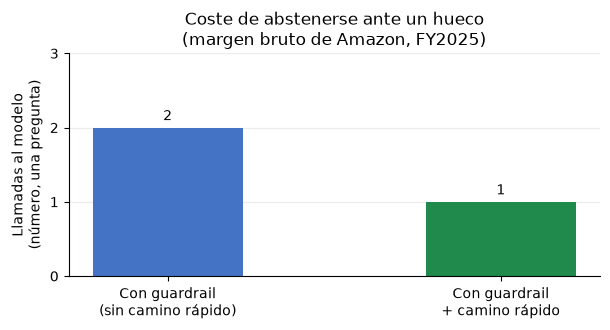

In [14]:
# Resumen de §3 en una tabla y un gráfico, construidos con lo que acaban de devolver las celdas de arriba.
tabla_hueco = pd.DataFrame([
    {"situación": "Lo que el modelo quería responder",
     "fuente declarada": "ambas", "cifra": "50,28 %",
     "llamadas al modelo": modelo_hueco.n},
    {"situación": "Con guardrail (sin camino rápido)",
     "fuente declarada": r_hueco.fuente, "cifra": r_hueco.cifra if r_hueco.cifra is not None else "—",
     "llamadas al modelo": modelo_hueco.n},
    {"situación": "Con guardrail + camino rápido",
     "fuente declarada": r_rapido.fuente, "cifra": r_rapido.cifra if r_rapido.cifra is not None else "—",
     "llamadas al modelo": modelo_rapido.n},
])
display(tabla_hueco.set_index("situación"))

fig, ax = plt.subplots(figsize=(6.2, 3.4))
_etq = ["Con guardrail\n(sin camino rápido)", "Con guardrail\n+ camino rápido"]
_val = [modelo_hueco.n, modelo_rapido.n]
_b = ax.bar(_etq, _val, color=[COLOR_NEUTRO, COLOR_CON], width=0.45)
ax.bar_label(_b, labels=[f"{v}" for v in _val], padding=3)
ax.set_ylabel("Llamadas al modelo\n(número, una pregunta)")
ax.set_ylim(0, max(_val) + 1)
ax.set_yticks(range(0, max(_val) + 2))
ax.set_title("Coste de abstenerse ante un hueco\n(margen bruto de Amazon, FY2025)")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

**Qué demuestra:** la respuesta con 50,28 % se convierte en «el dato no está en el corpus». Sin camino rápido
hay dos llamadas al modelo (decidir la consulta y proponer la respuesta); con él basta una. No se ha medido
ahorro monetario y el guion no demuestra cómo actuaría cualquier modelo real.

### 3.1. «No está, pero estimo…» y cifras escondidas en la explicación

Dejar `cifra=null` no basta. Se prueban un porcentaje estimado, un importe estimado y una afirmación numérica
escrita solo en `respuesta`. Todos deben acabar sin cantidades, sin estimaciones y sin reintento.

In [15]:
filas_honestidad = []
for fuente, texto in [
    ("ninguna", "No está en el corpus, pero estimo un margen del 50,28 %."),
    ("ninguna", "No está disponible, pero estimo 99.999 millones de USD."),
    ("xbrl", "El margen bruto fue de 50,28 %."),
    ("xbrl", "El dato equivale a 99.999 millones de USD."),
]:
    res_est, modelo_est = correr_agente([
        tc("get_xbrl_fact", AMZN_GROSS_2025, 1),
        respuesta_final(2, fuente=fuente, cifra=None, ticker="AMZN", ejercicio=2025, respuesta=texto),
    ], middleware=g.middleware_final(camino_rapido=False), pregunta=PREGUNTA_HUECO)
    r_est = res_est["structured_response"]
    assert r_est.fuente == "ninguna" and r_est.cifra is None and r_est.cifra_base is None
    assert not g.importes_prosa(r_est.respuesta) and g._sin_estimacion(r_est.respuesta)
    assert modelo_est.n == 2 and res_est["guard"]["reintentos"] == 0
    filas_honestidad.append({"intento del modelo": texto, "salida": r_est.respuesta,
                            "fuente final": r_est.fuente, "reintentos": res_est["guard"]["reintentos"]})
display(pd.DataFrame(filas_honestidad))

,intento del modelo,salida,fuente final,reintentos
0,"No está en el corpus, pero estimo un margen de...",No reportado en XBRL para AMZN FY2025: el dato...,ninguna,0
1,"No está disponible, pero estimo 99.999 millone...",No reportado en XBRL para AMZN FY2025: el dato...,ninguna,0
2,"El margen bruto fue de 50,28 %.",No reportado en XBRL para AMZN FY2025: el dato...,ninguna,0
3,El dato equivale a 99.999 millones de USD.,No reportado en XBRL para AMZN FY2025: el dato...,ninguna,0


## 4. Diagnóstico opcional con un modelo real

Activa `EJECUTAR=True` en parámetros para ejecutar tres preguntas fijadas de antemano: numérica (`g3-001`),
comparativa (`g3-014`) y dato ausente (`g3-h001`). Se usa `MODELO_REAL` con el sistema final y sus herramientas
reales. Este apartado requiere la clave del proveedor y puede consumir cuota; con `False` no hay llamadas.

Las referencias del golden solo se usan después para comprobaciones: el agente recibe únicamente la pregunta.
No se llama a un juez LLM. La explicación comparativa requiere revisión humana: cifra y cita literal correctas
no prueban por sí solas el acierto completo. El modelo puede acertar a la primera; por eso las demos controladas
siguen siendo necesarias para demostrar los reintentos.

Cada ejecución activa guarda un JSON nuevo en `resultados/diagnostico_guardrails/`, con respuestas, consultas,
observaciones y diagnóstico. No sustituye la evaluación del notebook 7 ni sobrescribe las tandas oficiales.
Los errores técnicos se identifican y detienen la tanda; no se presentan como fallos financieros demostrados.

In [16]:
from datetime import datetime, timezone
import json
import uuid
from agente10k import agente, evaluacion, evaluadores

resultados_reales, filas_reales = {}, []
ruta_diagnostico = None
if not EJECUTAR:
    print("Prueba real desactivada. Los apartados anteriores se han ejecutado sin API.")
else:
    if not config.cargar_clave():
        raise RuntimeError("Falta OPENROUTER_API_KEY en el entorno o en .env.")
    referencias = {p["id"]: p for archivo in ("golden_propio.jsonl", "golden_huecos.jsonl")
                   for p in evaluacion.cargar_golden(config.GOLDEN / archivo)}
    casos_reales = [("numérica", "g3-001"), ("comparativa", "g3-014"), ("dato ausente", "g3-h001")]
    sello = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
    ruta_diagnostico = config.RESULTADOS / "diagnostico_guardrails" / f"{sello}_{uuid.uuid4().hex[:8]}.json"
    ruta_diagnostico.parent.mkdir(parents=True, exist_ok=True)
    for caso, pid in casos_reales:
        p = referencias[pid]
        print(pid, "·", p["pregunta"], flush=True)
        try:
            ejecucion = agente.ejecutar(p["pregunta"], sistema="final", modelo=MODELO_REAL,
                                       fallbacks=(), usar_cache=False)
        except Exception as exc:
            ejecucion = {"error": type(exc).__name__, "respuesta": None}
        objeto = ejecucion.get("respuesta")
        respuesta = objeto.model_dump() if hasattr(objeto, "model_dump") else dict(objeto or {})
        error_tipo = str(ejecucion["error"]).split(":", 1)[0] if ejecucion.get("error") else None
        fila = {"id": pid, "golden": p, "respuesta": respuesta,
                "tool_calls": ejecucion.get("tool_calls") or [], "observaciones": ejecucion.get("observaciones") or []}
        puntuacion = evaluadores.puntuar_fila(fila, juez=None, estricto=True) if not error_tipo else {}
        guard = ejecucion.get("guard") or {}
        resultados_reales[pid] = {
            **fila, "caso": caso, "error_tipo": error_tipo, "guard": guard, "comprobaciones": puntuacion,
            "modelo_real": ejecucion.get("modelo_real"), "latencia_s": ejecucion.get("latencia_s"),
            "llamadas_modelo": ejecucion.get("llamadas_modelo"), "n_llamadas": ejecucion.get("n_llamadas"),
            "usd_openrouter": ejecucion.get("usd_openrouter"),
        }
        filas_reales.append({
            "id": pid, "caso": caso, "estado": "ERROR TÉCNICO" if error_tipo else "EJECUTADA: revisar evidencia",
            "error": error_tipo, "fuente": respuesta.get("fuente"), "cifra_ok": puntuacion.get("b"),
            "ambas_cifras_ok": puntuacion.get("b_con_base") if caso == "comparativa" else None,
            "cita_literal_y_vista": bool(puntuacion.get("a_existe") and puntuacion.get("a_vista")) if caso == "comparativa" and not error_tipo else None,
            "abstencion_ok": bool(puntuacion.get("acierto") and respuesta.get("cifra_base") is None) if caso == "dato ausente" and not error_tipo else None,
            "reintentos": guard.get("reintentos"), "retirada": guard.get("degradada"),
        })
        # Guarda después de cada caso: conserva una tanda parcial si el proveedor falla.
        ruta_diagnostico.write_text(json.dumps({
            "tipo": "diagnostico_no_oficial", "fecha_utc": sello, "modelo_solicitado": MODELO_REAL,
            "sistema": "final", "juez": None, "casos_previstos": [pid for _, pid in casos_reales],
            "resultados": resultados_reales,
        }, ensure_ascii=False, indent=2, default=str), encoding="utf-8")
        print("Respuesta:", respuesta.get("respuesta") or "(sin respuesta)")
        if error_tipo:
            print("Tanda detenida por fallo técnico; se conserva lo ejecutado.")
            break
    display(pd.DataFrame(filas_reales))
    print("Diagnóstico guardado en:", ruta_diagnostico.relative_to(RAIZ))
    print("Revisar manualmente la explicación comparativa y su evidencia.")

g3-001 · ¿Cuál fue el beneficio bruto de NVDA en el ejercicio fiscal 2024?
Respuesta: NVDA FY2024: beneficio bruto = 44.301 millones de USD (concepto XBRL GrossProfit).
g3-014 · ¿Cómo evolucionó los ingresos totales de MSFT entre los ejercicios fiscales 2024 y 2025, y qué explica la dirección al respecto?
Respuesta: No he podido verificar la explicación con una cita de los fragmentos consultados.
g3-h001 · ¿Cuál fue el margen bruto de AMZN en el ejercicio fiscal 2025?
Respuesta: No reportado en XBRL para AMZN FY2025: el dato no está en el corpus.


,id,caso,estado,error,fuente,cifra_ok,ambas_cifras_ok,cita_literal_y_vista,abstencion_ok,reintentos,retirada
0,g3-001,numérica,EJECUTADA: revisar evidencia,None,xbrl,True,None,None,None,0,False
1,g3-014,comparativa,EJECUTADA: revisar evidencia,None,xbrl,True,True,False,None,1,True
2,g3-h001,dato ausente,EJECUTADA: revisar evidencia,None,ninguna,True,None,None,True,0,False


Diagnóstico guardado en: resultados\diagnostico_guardrails\20260924T145337Z_d0276995.json
Revisar manualmente la explicación comparativa y su evidencia.


In [17]:
from IPython.display import JSON
ID_REAL_A_REVISAR = "g3-014"  # También g3-001 y g3-h001, si llegaron a ejecutarse.
if ID_REAL_A_REVISAR in resultados_reales:
    display(JSON(resultados_reales[ID_REAL_A_REVISAR]))
else:
    print("No hay una ejecución real de este caso en la tanda actual.")

<IPython.core.display.JSON object>

## 5. Cierre: qué queda demostrado y qué se mide fuera

Los apartados 1–3 comprueban protecciones concretas con errores controlados y datos del corpus. No miden
cuánto mejora un modelo real en el golden. El apartado 4 aporta un diagnóstico de integración, no una
medición oficial ni un juicio semántico automático.

Ya existen resultados de la evaluación oficial en `resultados/final/`, explicados en el
[notebook 7](07_sistema_final.ipynb). Son resultados de la versión con la que se ejecutó aquella tanda:
**no se recalculan ni se atribuyen automáticamente a los nuevos guardrails**. Para medir esta versión debe
utilizarse una etiqueta nueva y comparar agente y juez en condiciones equivalentes.

Las regresiones se ejecutan sin red con el Python del entorno del proyecto:

```text
python -m pytest -q tests/test_guardrails_cierre.py tests/test_guardrails_middleware.py tests/test_guardrails_verificador.py tests/test_guardrails_revision.py tests/test_guardrails_replay.py
```

In [18]:
resumen_requisitos = pd.DataFrame([
    {"requisito": "R04 · límites", "demostración": "10 llamadas al modelo, 9.ª herramienta bloqueada y 2.ª lectura bloqueada; rescate del FY pedido",
     "pruebas": "test_guardrails_middleware.py y test_guardrails_cierre.py"},
    {"requisito": "R05 · cifras", "demostración": "Reparación de escala/orientación, reintento y retirada; concepto solicitado y prosa",
     "pruebas": "test_guardrails_verificador.py, test_guardrails_cierre.py y test_guardrails_replay.py"},
    {"requisito": "Citas · literalidad y procedencia", "demostración": "Cita inventada: corregida o descartada tras un reintento; sin garantía semántica general",
     "pruebas": "test_guardrails_middleware.py"},
    {"requisito": "R14 · honestidad", "demostración": "Hueco real, camino rápido y estimaciones ocultas en el texto",
     "pruebas": "test_guardrails_middleware.py y test_guardrails_cierre.py"},
])
display(resumen_requisitos)

,requisito,demostración,pruebas
0,R04 · límites,"10 llamadas al modelo, 9.ª herramienta bloquea...",test_guardrails_middleware.py y test_guardrail...
1,R05 · cifras,"Reparación de escala/orientación, reintento y ...","test_guardrails_verificador.py, test_guardrail..."
2,Citas · literalidad y procedencia,Cita inventada: corregida o descartada tras un...,test_guardrails_middleware.py
3,R14 · honestidad,"Hueco real, camino rápido y estimaciones ocult...",test_guardrails_middleware.py y test_guardrail...
